# Regresión lineal

En este notebook trabajaremos con datos simulados para estudiar:

- cómo se ajusta una regresión lineal
- cómo se evalúa un modelo de regresión
- cómo cambia el ajuste frente a outliers
- cómo funciona Gradient Descent
- cómo Ridge, Lasso y Elastic Net modifican los coeficientes.


Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)



## Instrucciones

Este notebook combina celdas demostrativas con preguntas de análisis.

No basta con ejecutar el código: deben interpretar los resultados, comparar métricas y justificar sus respuestas usando gráficos, coeficientes y residuos.

In [5]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from sklearn import metrics
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict
from sklearn.model_selection import KFold
from sklearn import linear_model # Nuevo modelo desbloqueado

font = {'size'   : 16}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=14)
matplotlib.rc('ytick', labelsize=14)
#matplotlib.rcParams.update({'figure.autolayout': False})
matplotlib.rcParams['figure.dpi'] = 300

In [6]:
from sklearn.metrics._scorer import _SCORERS

#### Generamos un dataset de juguete

Primero trabajaremos con datos simulados. La ventaja es que conocemos la relación verdadera:
$$
y_{\rm true} = 3x + 3
$$

Luego agregamos ruido para simular mediciones imperfectas.

In [7]:
np.random.seed(16) #fijar semilla para la reproducibilidad

x = np.arange(100)

yp = 3*x + 3 + 2*(np.random.poisson(3*x+3,100)-(3*x+3))
#genera datos con dispersión, siguiendo una distribución Poissoniana
# con valor esperado = y (modelo lineal), centrado alrededor de cero

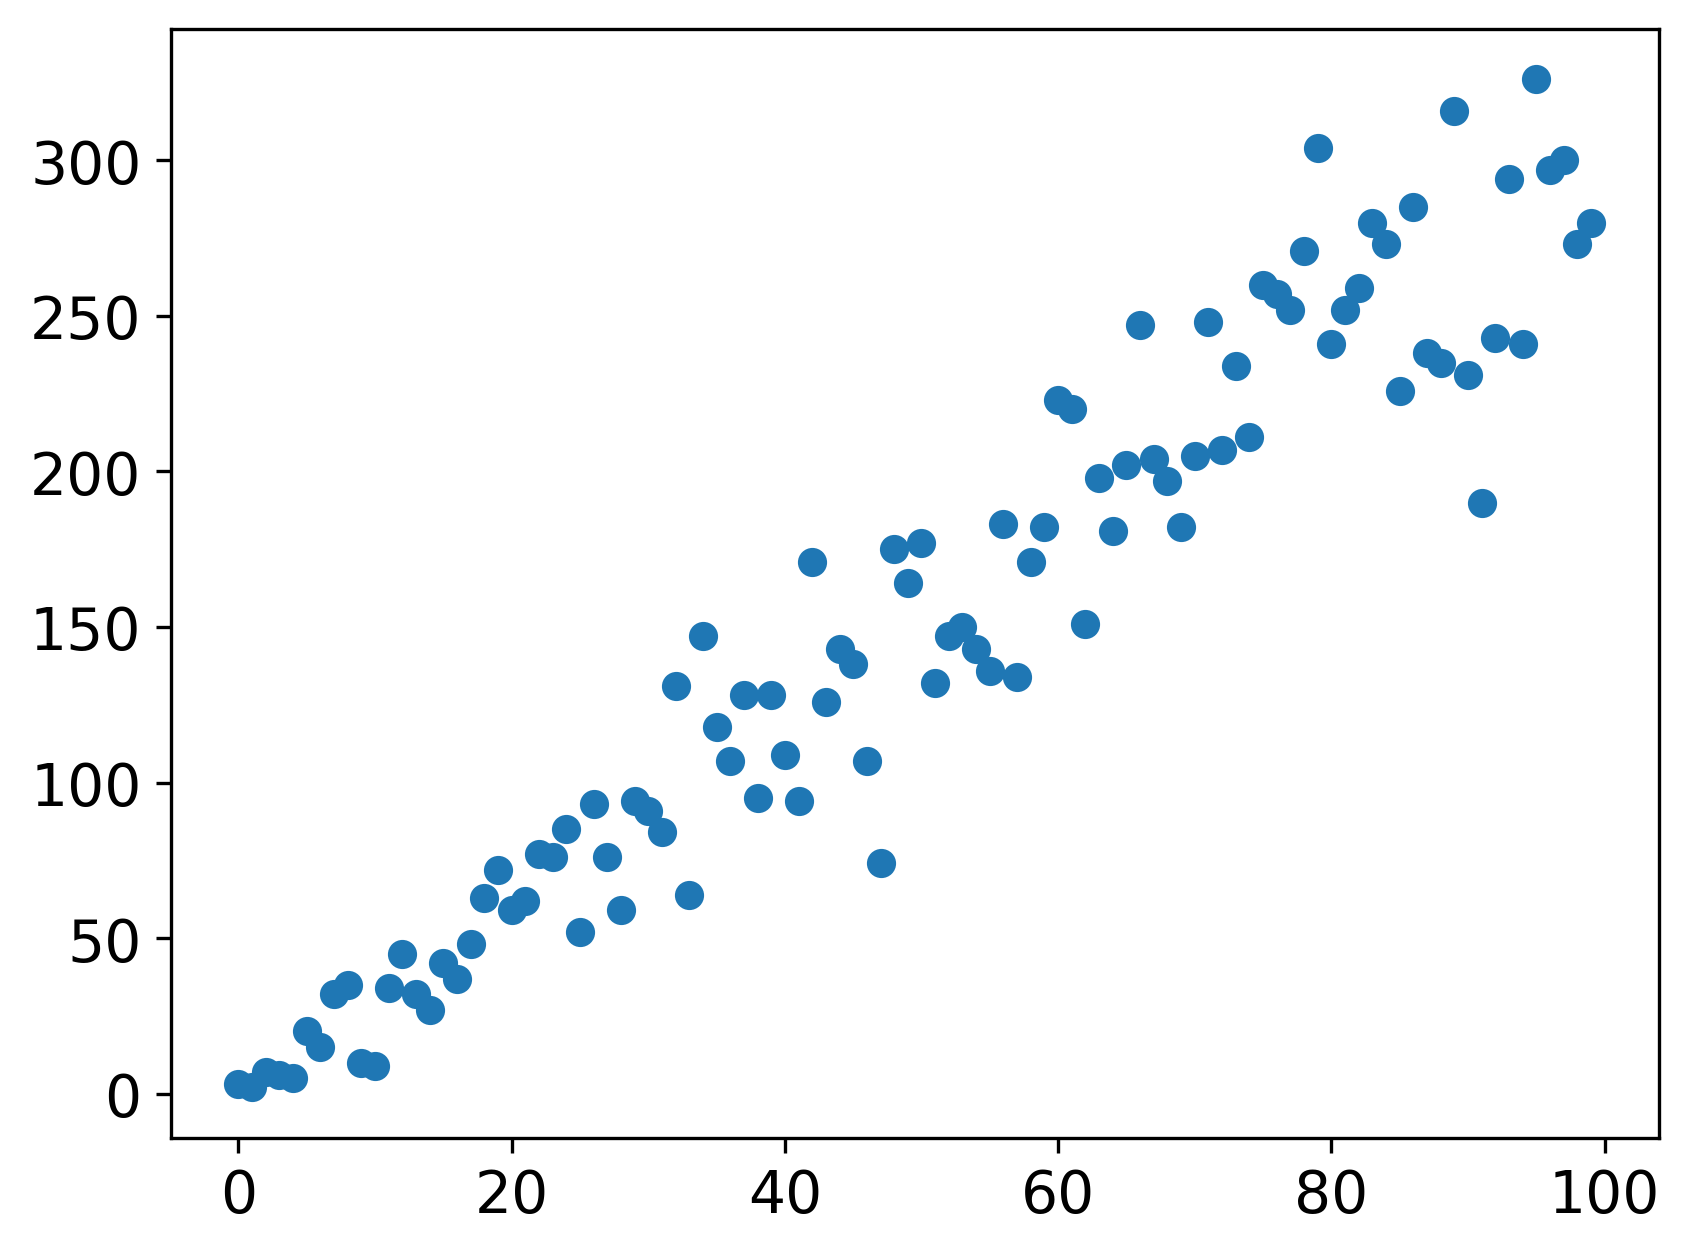

In [8]:
plt.scatter(x, yp);

### Pregunta

De acuerdo al gráfico anterior:
- ¿Los datos siguen una tendencia aproximadamente lineal?
- ¿La dispersión alrededor de la recta parece constante para todos los valores de \(x\)?
- ¿Qué podría implicar esto al mirar residuos más adelante?

**Respuestas**



*   Sí, los datos siguen una tendencia aproximadamente lineal. Observamos que a medida que aumenta x también aumenta y.

*   La dispersión no parece constante del todo, ya que para valores grandes de x los puntos parecen dispersarse un poco más.

*   Implica que aunque existe ruido estadístico agregado a los datos la linealidad sigue siendo dominante.






In [14]:
model = linear_model.LinearRegression()

#### Ajuste con regresión lineal

Ajustaremos un modelo de la forma:

$$
\hat{y} = \beta_0 + \beta_1 x
$$

En `sklearn`, cuando tenemos una sola feature, necesitamos escribir `x` como una matriz de forma `(n_samples, 1)`. Por eso usamos:

```python
x.reshape(-1, 1)

In [10]:
model.fit(x.reshape(-1, 1), yp)

LinearRegression()

In [11]:
slope = model.coef_[0]
intercept = model.intercept_

print(f"Intercepto beta_0 = {intercept:.3f}")
print(f"Pendiente beta_1 = {slope:.3f}")

Intercepto beta_0 = -0.126
Pendiente beta_1 = 3.025


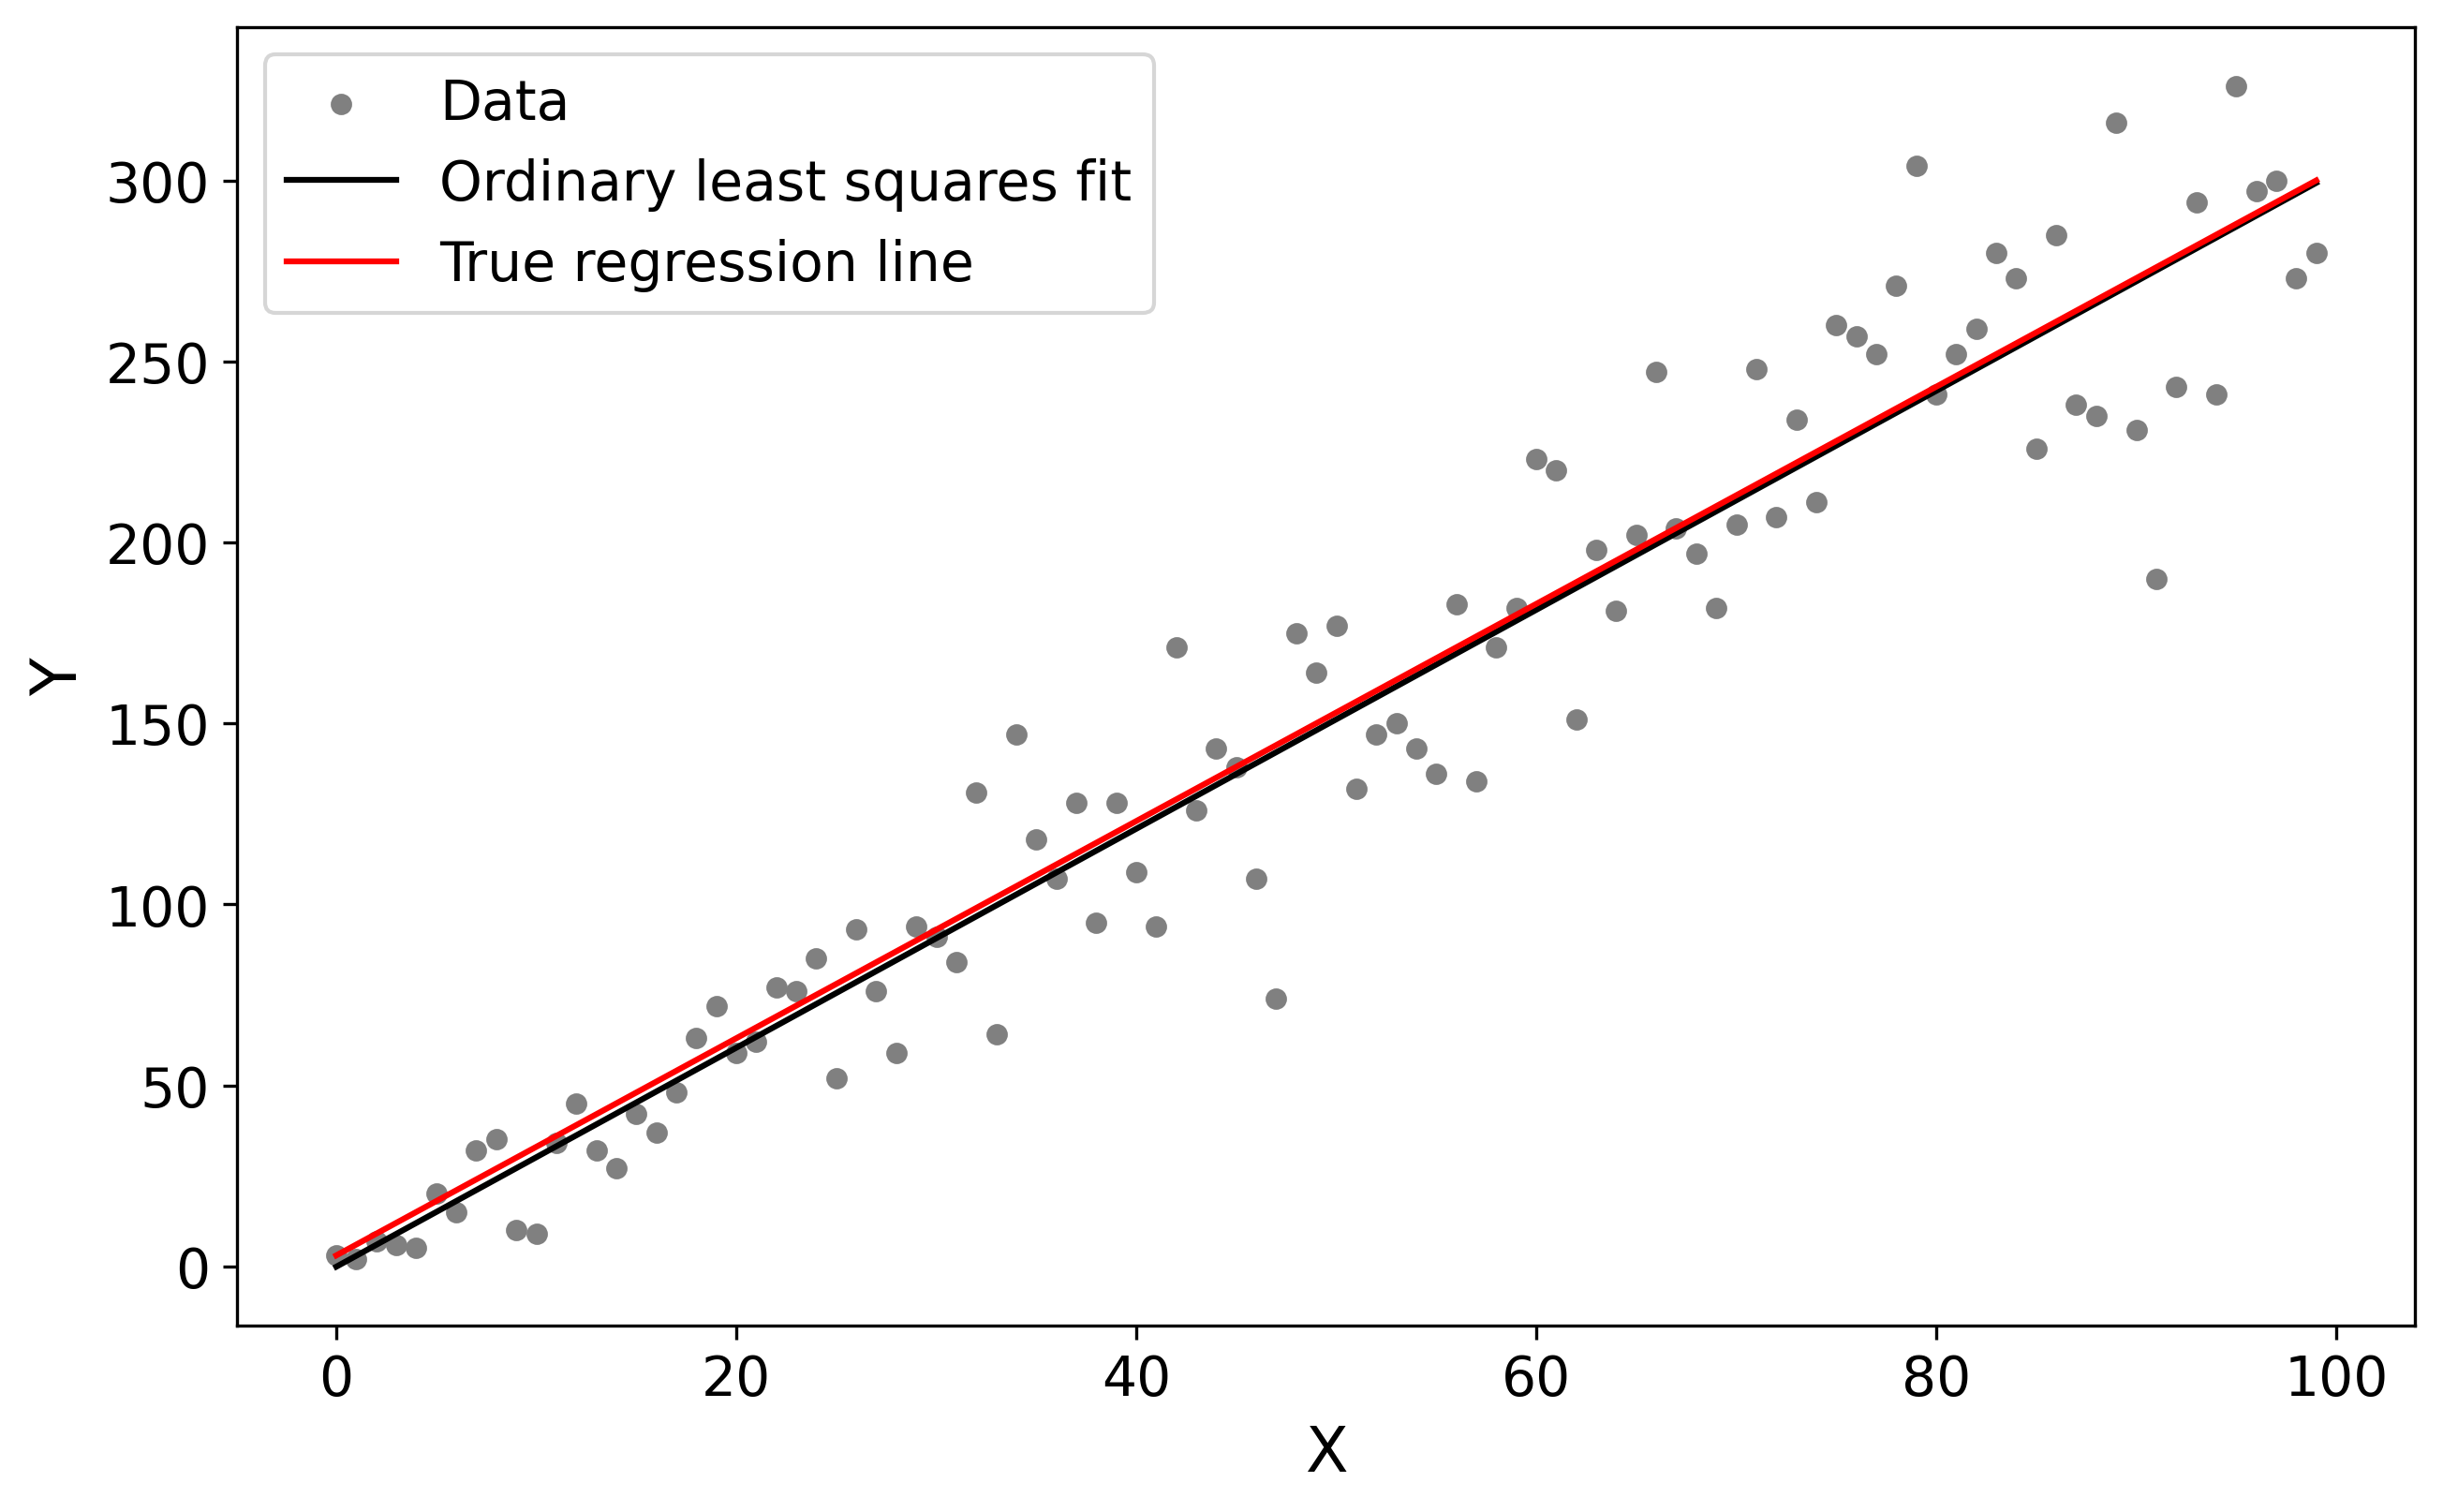

In [12]:
plt.figure(figsize = (10,6))
plt.scatter(x,yp, s = 20, c = 'gray', label = 'Data')
plt.plot(x, slope*x + intercept, c ='k', label = 'Ordinary least squares fit')
plt.plot(x, 3*x + 3, c = 'r', label = 'True regression line')
plt.legend(fontsize = 14)
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

### Pregunta

Compara los coeficientes ajustados con los valores verdaderos $\beta_0=3$ y $\beta_1=3$
-  ¿Son exactamente iguales? ¿Por qué?
-  ¿Qué representa físicamente/matemáticamente la pendiente en este modelo?

**Respuestas**

*  Los coeficientes ajustados son cercanos a los valores verdaderos
beta0=3 y beta1=3, aunque no coinciden del todo. Esto ocurre porque los datos contienen ruido aleatorio, por lo que la regresión lineal estima los parámetros que minimizan el error promedio sobre las observaciones disponibles y no recupera exactamente los parámetros originales.

*  La pendiente representa cuánto cambia la variable objetivo y cuando la variable x aumenta en una unidad. Matemáticamente, es la tasa de cambio de la recta.

#### Solución analítica de mínimos cuadrados

Para regresión lineal simple, la pendiente que minimiza el MSE puede escribirse como:

$$
\beta_1 =
\frac{\sum_i (x_i-\bar{x})(y_i-\bar{y})}
{\sum_i (x_i-\bar{x})^2}
$$

y luego:

$$
\beta_0 = \bar{y} - \beta_1\bar{x}
$$

**Implemente en el código para calcular a partir de la solución analítica los coeficientes y compare**

In [15]:
beta1 = np.cov(x, yp, bias=True)[0,1] / np.var(x)
beta0 = np.mean(yp) - beta1*np.mean(x)

print(f"Beta_0 analítico = {beta0:.3f}")
print(f"Beta_1 analítico = {beta1:.3f}")

Beta_0 analítico = -0.126
Beta_1 analítico = 3.025


#### Evaluación del modelo: validación cruzada y métricas

Ahora aplicamos una idea que ya usamos en clasificación: validar el modelo en distintos subconjuntos de datos.

Por defecto, `LinearRegression.score()` devuelve \(R^2\), no accuracy.

Podemos ver todos los scorers implementados en sklearn

In [16]:
from sklearn.metrics import get_scorer_names
print(get_scorer_names())

['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'average_precision', 'balanced_accuracy', 'completeness_score', 'd2_absolute_error_score', 'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef', 'mutual_info_score', 'neg_brier_score', 'neg_log_loss', 'neg_max_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'neg_negative_likelihood_ratio', 'neg_root_mean_squared_error', 'neg_root_mean_squared_log_error', 'normalized_mutual_info_score', 'positive_likelihood_ratio', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'r2', 'rand_score', 'recall', 'recall_macro', 'recall_micro', 'recall_samples'

#### Implemente una validación cruzada con Kfold

y encuentre los resultados para las métricas R^2, 'neg_mean_absolute_error'  (MAE) y 'neg_mean_squared_error' (MSE)

Para los estimadores de la performance del modelo del tipo "error" siempre queremos que sean pequeños (menor error, mejor modelo). Pero en sklearn, reciben un signo negativo, como neg_mean_squared_error, para mantener la consistencia de "alto puntaje=mejor" de los scorers

In [57]:
from sklearn.model_selection import KFold, cross_validate

kfold = KFold(n_splits=5, shuffle=True, random_state=16)

scores_r2 = cross_validate(
    model,
    x.reshape(-1,1),
    yp,
    cv=kfold,
    scoring='r2',
    return_train_score=True
)

print(f"R2 test : {scores_r2['test_score'].mean():.3f} ± {scores_r2['test_score'].std():.3f}")
print(f"R2 train: {scores_r2['train_score'].mean():.3f} ± {scores_r2['train_score'].std():.3f}")

R2 test : 0.918 ± 0.052
R2 train: 0.925 ± 0.011


In [21]:
scores_mse = cross_validate(
    model,
    x.reshape(-1,1),
    yp,
    cv=kfold,
    scoring='neg_mean_squared_error')

scores_mae = cross_validate(
    model,
    x.reshape(-1,1),
    yp,
    cv=kfold,
    scoring='neg_mean_absolute_error')

print(f"MSE : {-scores_mse['test_score'].mean():.3f}")
print(f"MAE : {-scores_mae['test_score'].mean():.3f}")

MSE : 640.938
MAE : 19.160


**Haga un gráfico de los residuos $r_i=y_i-\hat{y}_i$**

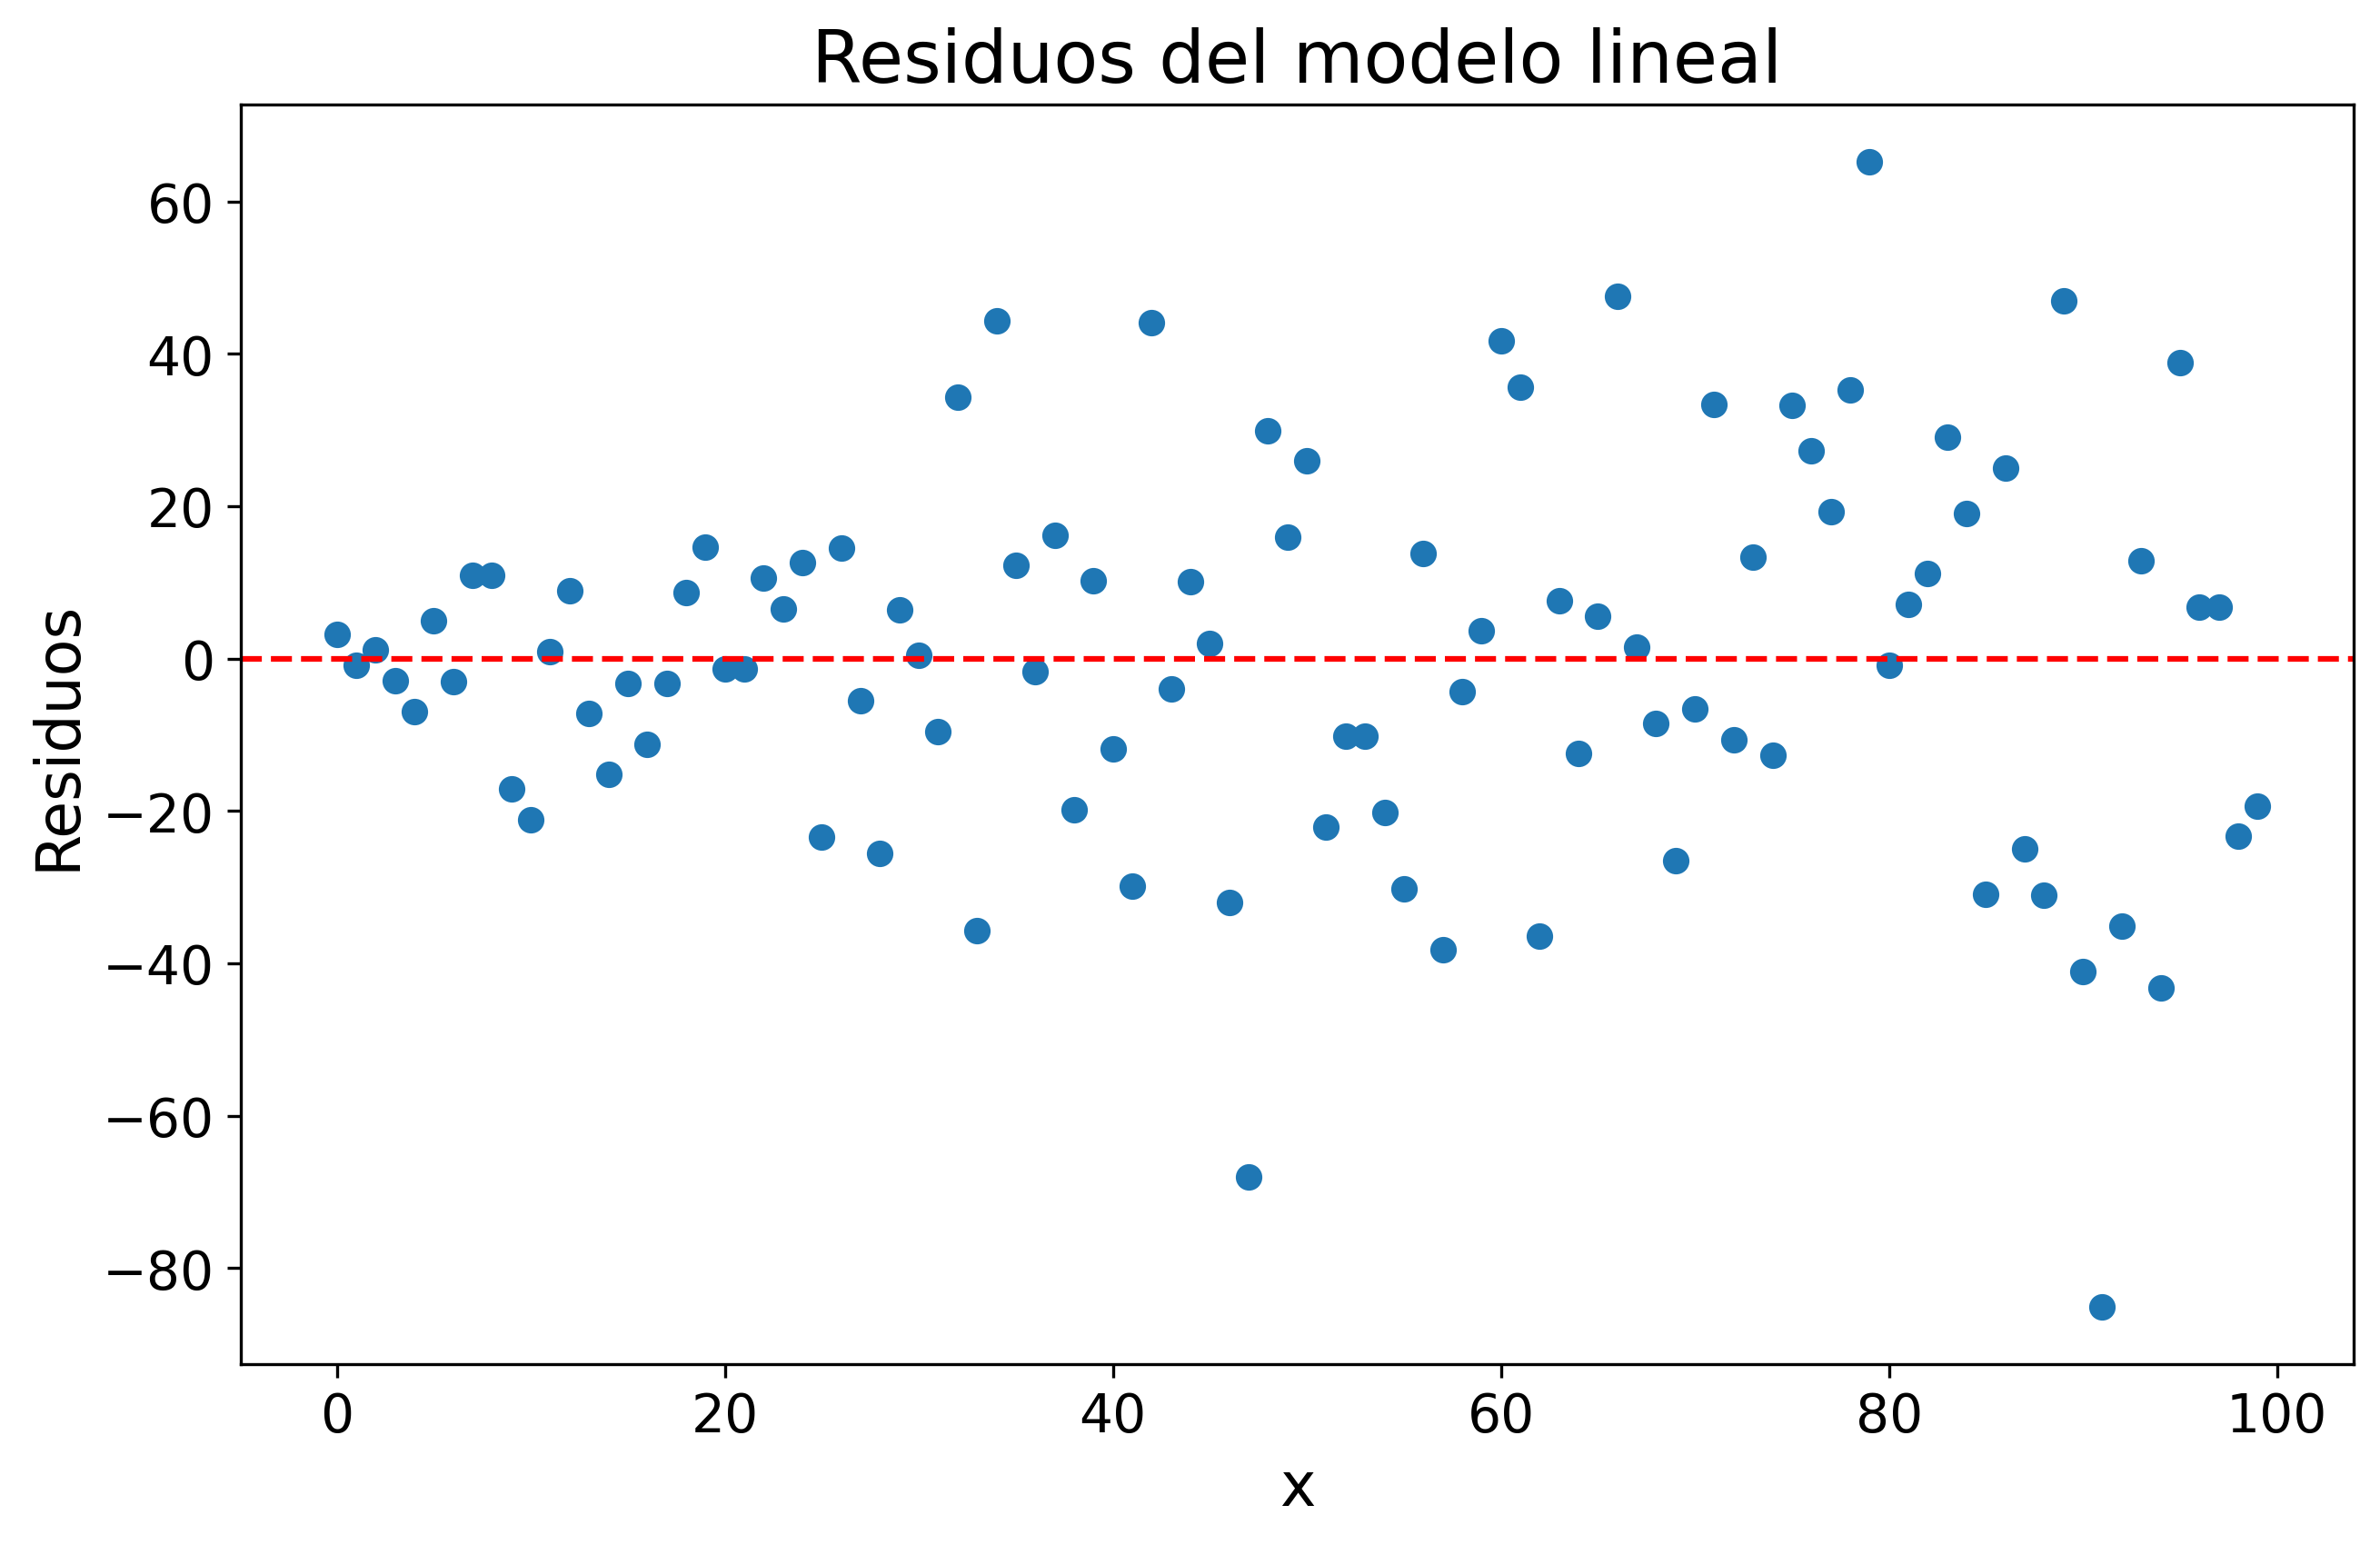

In [24]:
model.fit(x.reshape(-1,1), yp)

yp_pred = model.predict(x.reshape(-1,1))
residuos = yp - yp_pred

plt.figure(figsize=(10,6))
plt.scatter(x, residuos)
plt.axhline(0, color='red', linestyle='--')

plt.xlabel('x')
plt.ylabel('Residuos')
plt.title('Residuos del modelo lineal')

plt.show()

#### Pregunta
-  ¿Los residuos parecen distribuidos aleatoriamente alrededor de cero?
-  ¿La dispersión de los residuos cambia con $x$?
-  ¿Qué nos dice esto sobre el modelo y/o sobre cómo fueron generados los datos?

**Respuestas**


*   Los residuos efectivamente parecen distribuidos aproximadamente alrededor de cero. Esto sugiere que el modelo lineal representa bastante bien la tendencia principal de los datos.

* La dispersión de los residuos no cambia mucho con x, aunque puede observarse una leve variación para algunos valores altos.


*  Nos indica que el modelo lineal es adecuado para describir los datos y que probablemente los datos fueron generados a partir de una relación lineal con ruido aleatorio agregado, sin patrones no lineales importantes ni errores sistemáticos evidentes.



### ¿Qué ocurre si agregamos outliers?

In [25]:
np.random.seed(12) # fijada la semilla
out = np.random.choice(100,15) #seleccionamos 15 índices de outliers
yp_wo = np.copy(yp)
np.random.seed(12) #fijada
yp_wo[out] = yp_wo[out] + 5*np.random.rand(15)*yp[out]

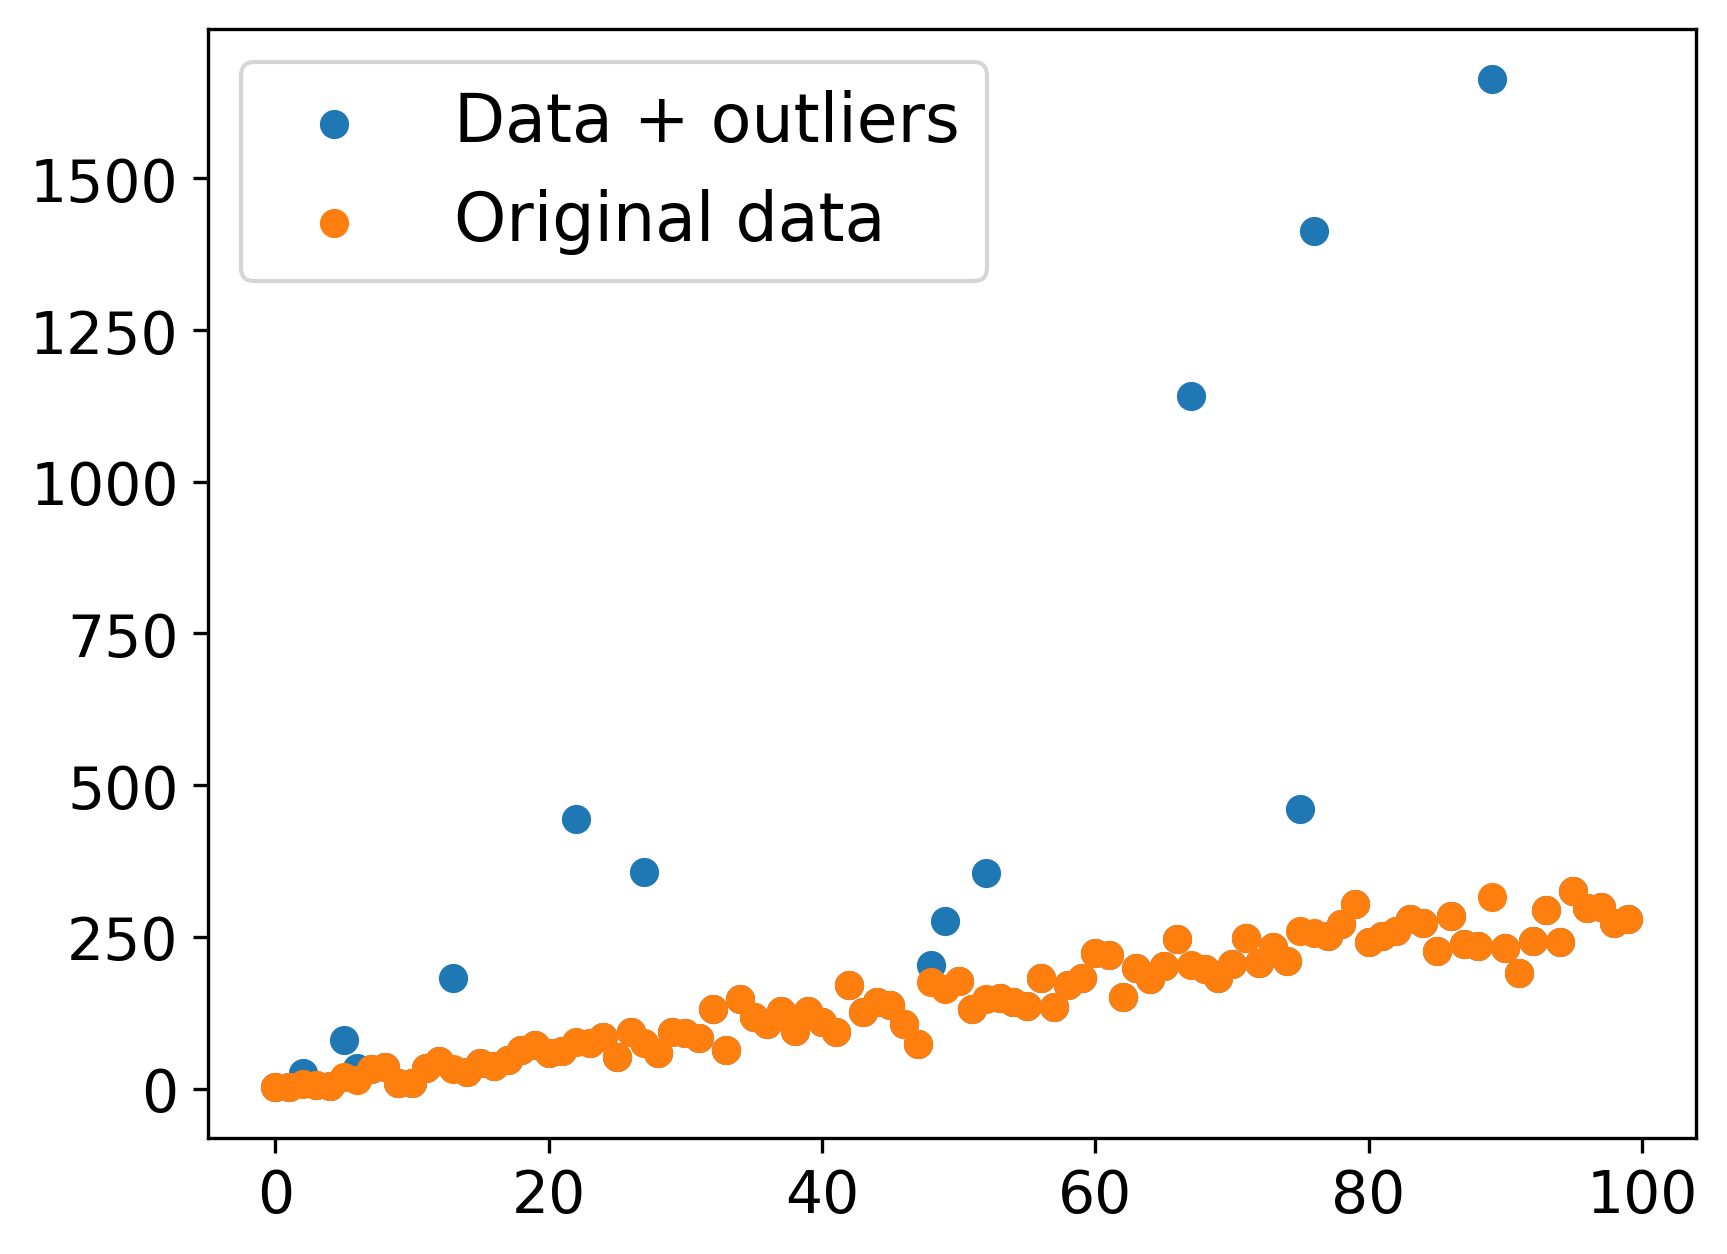

In [26]:
plt.scatter(x,yp_wo, label = 'Data + outliers')
plt.scatter(x,yp, label = 'Original data')
plt.legend();

#### Ajuste el modelo de regresión lineal para los datos con outliers

Responda:
- Compare visualmente el ajuste antes y después de agregar outliers. ¿La recta cambia mucho? ¿Hacia dónde se mueve?
- Compara los coeficientes $\beta_0$ y $\beta_1$ del modelo con y sin outliers.  ¿Cuál cambia más: el intercepto o la pendiente?
- Compara las métricas MAE, MSE, RMSE y $R^2$ antes y después de agregar outliers. ¿Qué métrica se ve más afectada?
- ¿Por qué el MSE/RMSE suele ser más sensible a outliers que el MAE?
- ¿Todos los outliers afectan de la misma manera al modelo? Observa si los puntos atípicos están lejos en $y$, lejos en $x$, o en ambos.
- ¿Dirías que el modelo con outliers está aprendiendo la tendencia general de los datos o está siendo “tirado” por algunos puntos extremos? Justifica.
- Si este fuera un dataset real, ¿eliminarías los outliers automáticamente? Explica qué revisarías antes de decidir.

**Respuestas**

* Sí, la recta ajustada cambia después de agregar outliers. El modelo intenta acercarse a los puntos extremos, por lo que la recta se desplaza hacia la región donde se encuentran esos valores atípicos.

* La pendiente β1 cambia más, ya que los outliers afectan principalmente la inclinación necesaria para minimizar el error total.

* Después de agregar outliers, todas las métricas empeoran, pero MSE y RMSE se ven más afectadas.

* El MSE y el RMSE elevan los errores al cuadrado, haciendo que los errores grandes contribuyan desproporcionadamente al valor final de la métrica. En cambio, el MAE utiliza el valor absoluto de los errores, por lo que todos los errores aportan de manera más uniforme.

* No todos los outliers afectan igual. Los puntos alejados en x suelen modificar fuertemente la pendiente de la recta, mientras que los alejados solo en y generan residuos grandes.

* El modelo está siendo parcialmente “tirado” por los puntos extremos, ya que aunque aún conserva cierta tendencia lineal general, la recta ajustada se desvía para intentar acomodar los outliers, perjudicando el ajuste sobre la mayoría de los datos.

* No eliminaría los outliers automáticamente. Primero revisaría si corresponden a errores experimentales, problemas de medición o fenómenos físicamente reales.

In [27]:
model_outliers = linear_model.LinearRegression()
model_outliers.fit(x.reshape(-1,1), yp_wo)

LinearRegression()

Del resultado del modelo lineal para estos datos con outliers, guarde los coeficientes encontrados en un array llamado `theta_ne`

In [58]:
theta_ne = np.array([
    [model_outliers.intercept_],
    [model_outliers.coef_[0]]])

print(theta_ne)

[[1.54811881]
 [3.97842184]]


Esto es la solución usando el modelo y la **ecuación normal**

### Ahora implementaremos 3 métodos de gradient descent: batch, estocástico y mini-batch

En esta sección ajustamos una regresión lineal usando Gradient Descent en vez de usar directamente `LinearRegression`. Compararemos con los resultados encontrados en la regresión con outliers.




Agregaremos $x_0=1$ a cada instancia, este es el término de bias ($\beta_0$) y se usa para escribir la solución en la forma de multiplicación de matrices

$y=X\cdot \theta$

donde $\theta$ es el vector de coeficientes que incluye el término $\beta_0$  (término de bias) y $\beta_1, \beta_2, \beta_3,..., \beta_n$

In [32]:
X = np.c_[np.ones((100, 1)), x]

print(X.shape) #la forma es el número de instancias x número de parámetros


(100, 2)


Podemos calcular la pérdida asociada con la ecuación normal, usando la expresión

$\text{MSE} = \frac{1}{m}\|X\cdot \theta - y \|^2$

In [33]:
loss_ne = np.mean((X.dot(theta_ne) - yp_wo.reshape(-1,1))**2)

### Batch GD

In [34]:
np.random.seed(10)

eta = 0.0001 #learning step (valor pequeño asegura convergencia, aunque lenta)
n_iterations = 1000 #puede cambiar este valor!!
m = 100 #número de instancias

theta_path_bgd = [] #arreglo para guardar los valores de los parámetros en cada iteración

theta = np.random.randn(2,1) #inicializamos con valores aleatorios

for iteration in range(n_iterations):
    gradients = 2/m * X.T.dot(X.dot(theta) - yp_wo.reshape(-1,1)) #gradiente de la función de pérdida respecto a theta
    theta = theta - eta * gradients #actualiza los valores de theta, en cada cálculo del gradiente, en cada paso
    theta_path_bgd.append(theta) #

theta_path_bgd = np.array(theta_path_bgd) #guardamos esos valores (útil para una visualización)

theta_bgd = theta #resultado final

In [35]:
theta_bgd

array([[1.38909891],
       [3.98081931]])

In [36]:
loss_bgd = np.sum(1/m*(X.dot(theta_bgd) - yp_wo.reshape(-1,1))**2)

In [37]:
loss_bgd

np.float64(43259.08804185896)

In [38]:
(loss_ne-loss_bgd)/loss_ne*100 #diferencia porcentual con la ecuación normal

np.float64(-1.4834194931614274e-05)

###  GD estocástico

In [39]:
np.random.seed(10) #

theta = np.random.randn(2,1)  #inicializa los parámetros

eta = 0.000005 #learning step, valor más pequeño evita saltos muy grandes

n_iterations = 10000 #necesitamos más iteraciones en este caso

theta_path_sgd = []

for epoch in range(n_iterations):

        random_index = np.random.randint(m) #índice aleatorio

        x_one = X[random_index:random_index+1] #sólo se selecciona una instancia del conjunto de datos (m es la cantidad total)

        y_one = yp_wo[random_index:random_index+1]

        gradients = 2 * x_one.T.dot(x_one.dot(theta) - y_one)
        theta = theta - eta * gradients
        theta_path_sgd.append(theta)

theta_path_sgd = np.array(theta_path_sgd)

theta_sgd = theta

In [40]:
theta_sgd

array([[1.3552955 ],
       [4.17721319]])

In [41]:
loss_sgd = np.sum(1/m*(X.dot(theta_sgd) - yp_wo.reshape(-1,1))**2)

In [42]:
loss_sgd

np.float64(43385.08132655123)

In [43]:
(loss_ne-loss_sgd)/loss_ne*100 #diferencia porcentual con la ecuación normal

np.float64(-0.29126763004779105)

### Mini batch GD

In [59]:
# See also implementation notes here: https://sebastianraschka.com/faq/docs/sgd-methods.html

np.random.seed(10)

theta = np.random.randn(2,1)

eta = 0.000005

n_iterations = 1000

theta_path_mgd = []

minibatch_size = 10

for epoch in range(n_iterations):

    shuffled_indices = np.random.permutation(m) #se desordena el arreglo para seleccionar distintos mini-batches

    X_shuffled = X[shuffled_indices]

    y_shuffled = yp_wo.reshape(-1,1)[shuffled_indices]

    xi = X_shuffled[:minibatch_size] #subset aleatorio para calcular el gradiente

    yi = y_shuffled[:minibatch_size]

    gradients = 2/minibatch_size * xi.T.dot(xi.dot(theta) - yi)

    theta = theta - eta * gradients

    theta_path_mgd.append(theta)

theta_path_mgd = np.array(theta_path_mgd)

theta_mgd = theta

print(theta_mgd)

[[1.38191988]
 [4.25542902]]


In [51]:
theta_mgd

array([[1.38191988],
       [4.25542902]])

In [52]:
loss_mgd = np.sum(1/m*(X.dot(theta_mgd) - yp_wo.reshape(-1,1))**2)

In [53]:
loss_mgd

np.float64(43506.50418469318)

In [54]:
(loss_ne-loss_mgd)/loss_ne*100 #diferencia porcentual con la ecuación normal

np.float64(-0.5719551841556246)

#### Comparación de GD
Veamos el camino que siguió cada método de GD que implementamos. El color más oscuro indica pasos posteriores

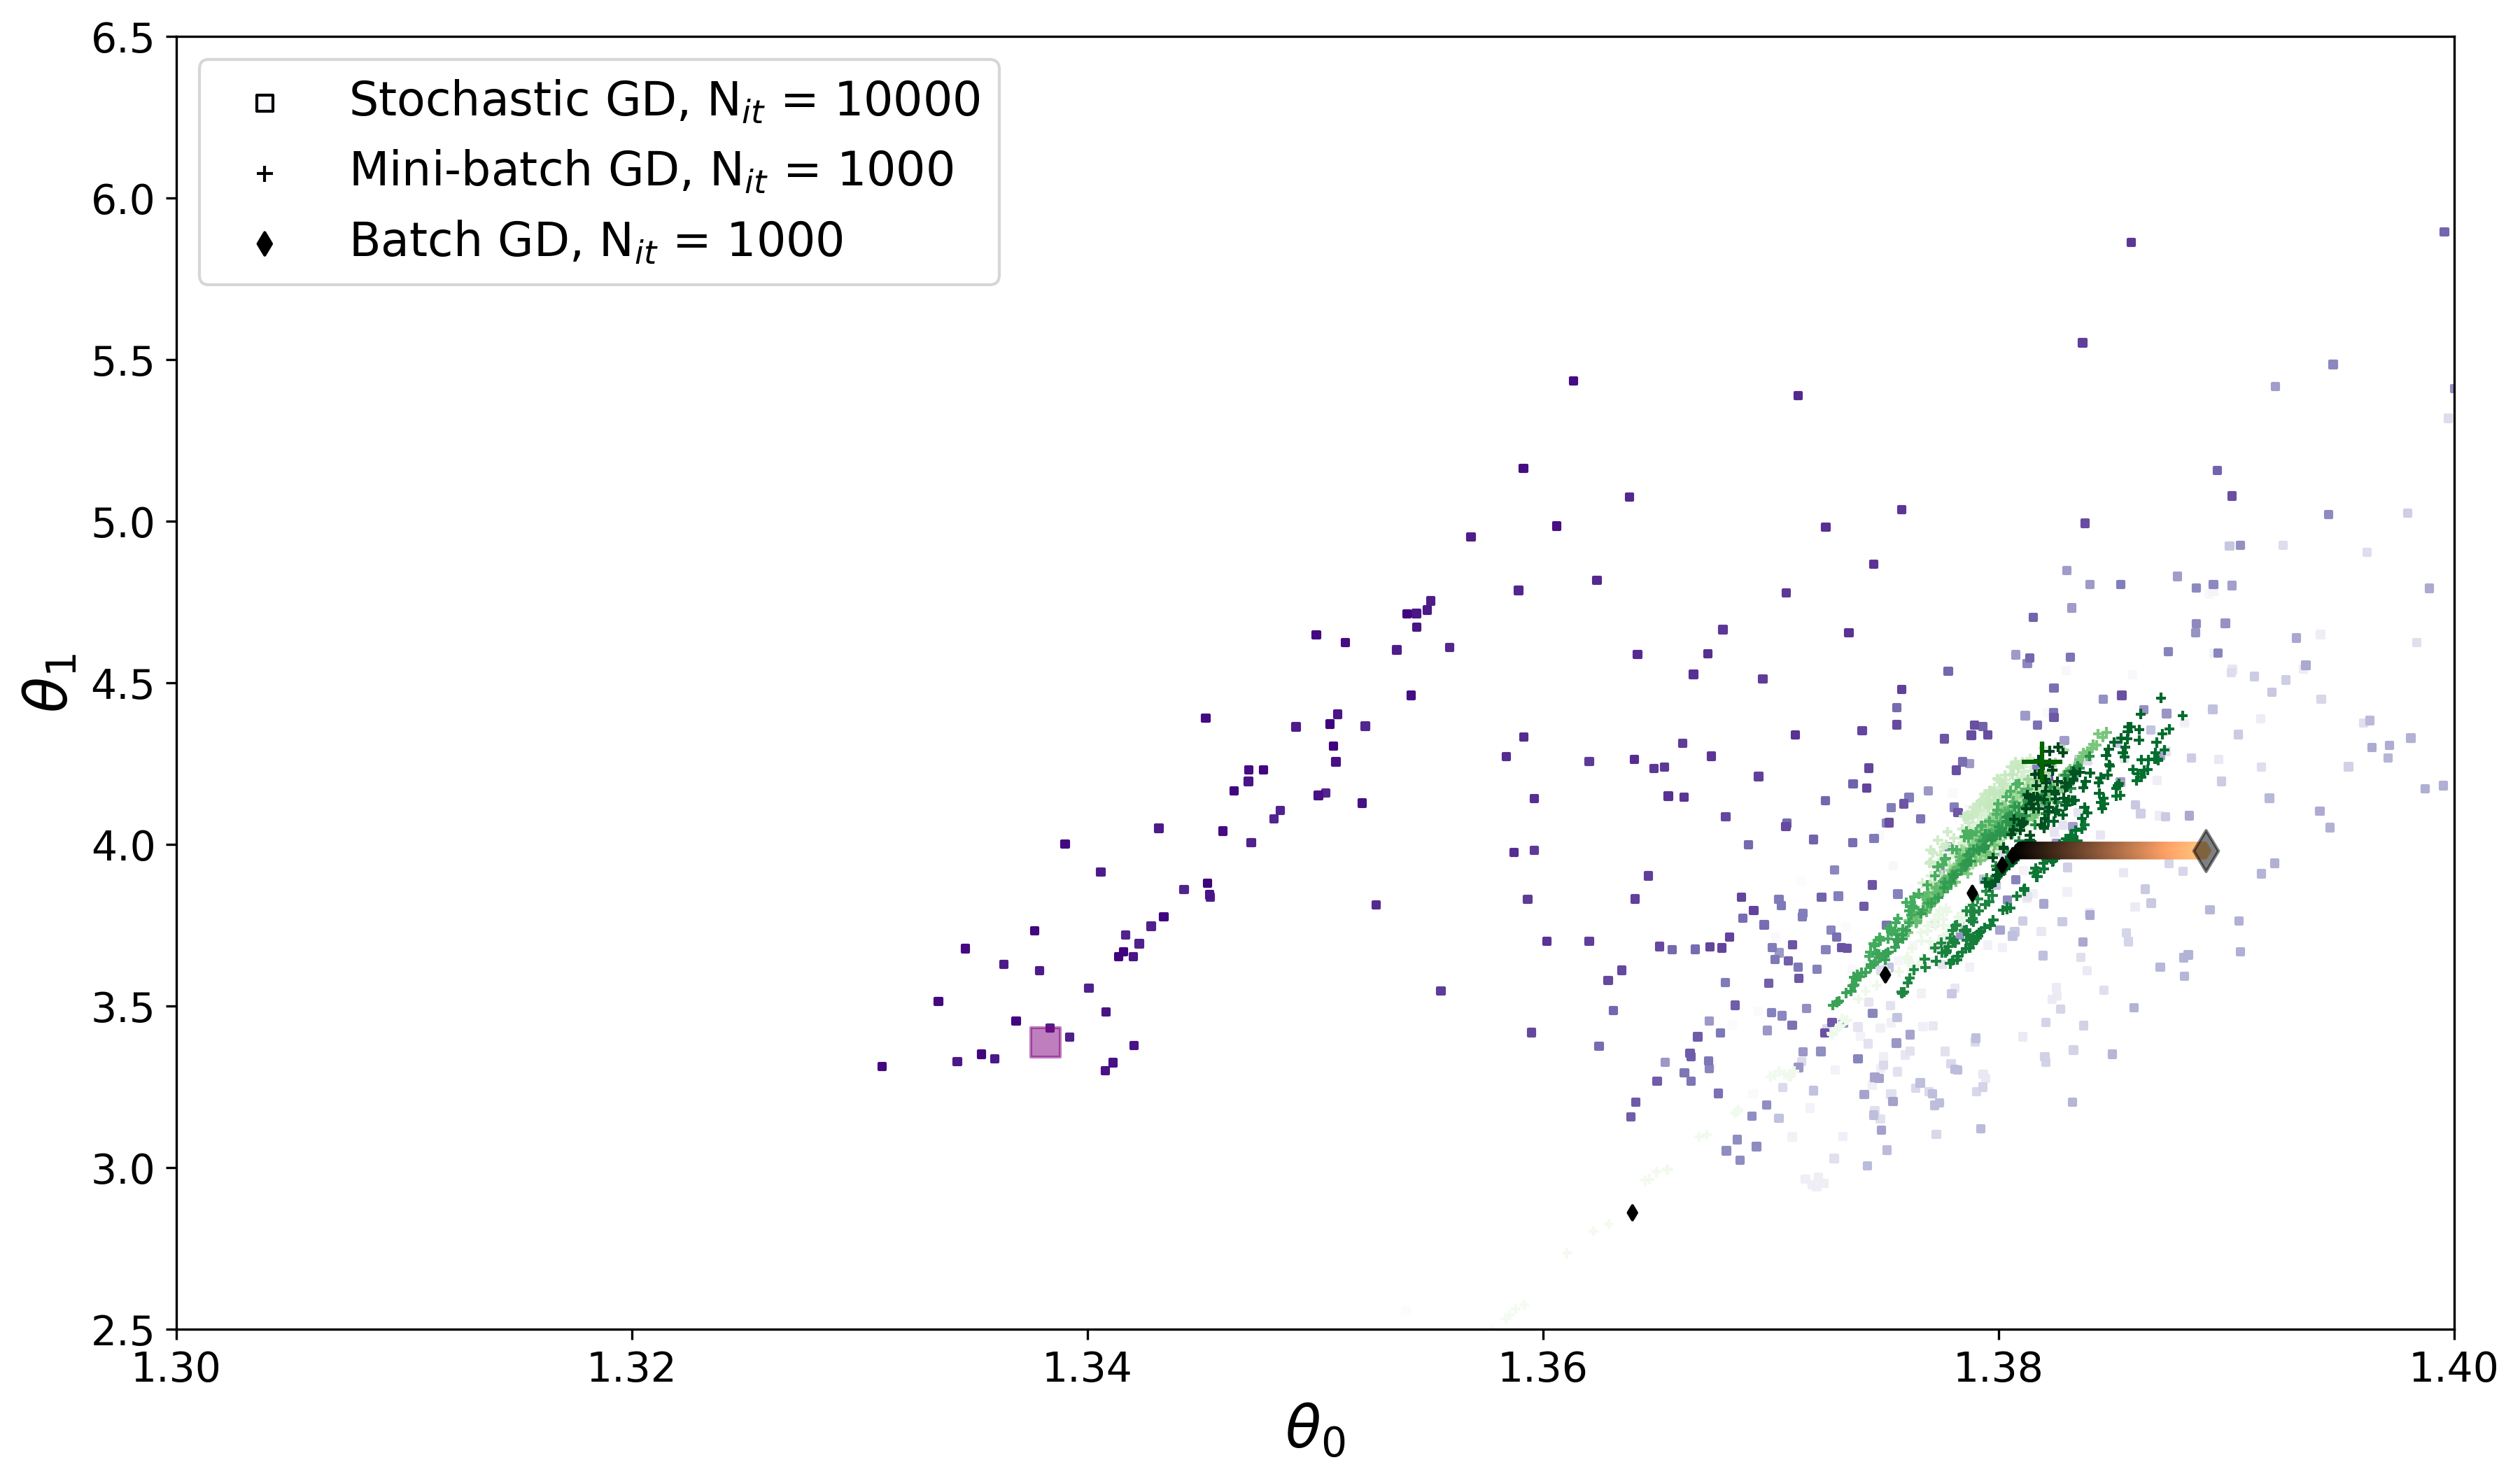

In [62]:
plt.figure(figsize=(14,8))

plt.scatter(
    theta_path_sgd[::10, 0].flatten(),
    theta_path_sgd[::10, 1].flatten(),
    marker='s',
    s=5,
    label="Stochastic GD, N$_{it}$ = 10000",
    c=np.arange(len(theta_path_sgd[::10])),
    cmap=plt.cm.Purples)

plt.scatter(
    theta_path_mgd[:, 0].flatten(),
    theta_path_mgd[:, 1].flatten(),
    marker="+",
    s=12,
    linewidth=1,
    label="Mini-batch GD, N$_{it}$ = 1000",
    c=np.arange(len(theta_path_mgd)),
    cmap=plt.cm.Greens)

plt.scatter(
    theta_path_bgd[:, 0].flatten(),
    theta_path_bgd[:, 1].flatten(),
    marker="d",
    s=12,
    linewidth=1,
    label="Batch GD, N$_{it}$ = 1000",
    c=np.arange(len(theta_path_bgd)),
    cmap=plt.cm.copper)

plt.scatter(
    theta_sgd[0],
    theta_sgd[1],
    marker="s",
    s=100,
    color='Purple',
    alpha=0.5
)

plt.scatter(
    theta_mgd[0],
    theta_mgd[1],
    marker="+",
    s=200,
    color='DarkGreen',
    alpha=1
)

plt.scatter(
    theta_bgd[0],
    theta_bgd[1],
    marker="d",
    s=100,
    color='k',
    alpha=0.5
)

legend = plt.legend(loc="upper left", fontsize=16)

for i in range(3):
    legend.legend_handles[i].set_color('k')
    legend.legend_handles[i]._sizes = [30]

plt.xlabel(r"$\theta_0$", fontsize=20)
plt.ylabel(r"$\theta_1$", fontsize=20)

plt.axis([1.3, 1.4, 2.5, 6.5])

plt.show()

### Preguntas

1. Identifica en el código de mini batch GD dónde ocurre cada paso:

   - cálculo de las predicciones
   - cálculo del error o residuo
   - cálculo del gradiente
   - actualización de los parámetros

2. ¿Qué representan los parámetros $\theta_0$ y $\theta_1$ en este modelo?

3. Compara los parámetros encontrados por Gradient Descent con los obtenidos mediante `LinearRegression`. ¿Son iguales o parecidos? ¿Por qué no necesariamente coinciden exactamente?


4. Cambia el learning rate $\eta$. Prueba al menos tres valores: uno pequeño, uno razonable y uno demasiado grande. ¿Qué ocurre en cada caso?


5. Explica con tus palabras por qué la actualización tiene un signo menos: $\theta \leftarrow \theta - \eta \nabla L$

6. En la solución analítica derivamos e igualamos a cero. En Gradient Descent no resolvemos directamente la ecuación.  ¿Qué hacemos en cambio?

7. Compara Batch Gradient Descent, Stochastic Gradient Descent y Mini-batch Gradient Descent.

   - ¿Cuál usa todos los datos en cada actualización?
   - ¿Cuál actualiza los parámetros con más ruido?
   - ¿Cuál parece converger de forma más suave?

**Respuestas**
1.    
   - cálculo de las predicciones: $xi.dot(theta)$
   - cálculo del error o residuo: $xi.dot(theta) - yi$
   - cálculo del gradiente: $gradients = 2/len(xi) * xi.T.dot(xi.dot(theta) - yi)$
   - actualización de los parámetros: $theta = theta - eta * gradients$

  2. El parámetro θ_0 representa el intercepto de la recta, es decir, el valor esperado de y cuando x=0. El parámetro θ_1 representa la pendiente de la recta y describe cuánto cambia y por cada unidad de incremento en x.

  3. Los parámetros encontrados mediante Gradient Descent son muy parecidos a los obtenidos con LinearRegression. Las pequeñas diferencias aparecen porque Gradient Descent es un método iterativo aproximado, mientras que LinearRegression utiliza la solución analítica exacta.

  4. Cuando el learning rate es muy pequeño, el algoritmo converge de manera muy lenta y requiere muchas iteraciones. Con un valor razonable, la convergencia es estable y eficiente. Cuando el learning rate es demasiado grande, las actualizaciones son excesivas y el algoritmo puede oscilar o incluso divergir sin alcanzar el mínimo.

5. El signo menos aparece porque el gradiente apunta hacia la dirección de mayor aumento de la función de pérdida. Como queremos minimizar el error, debemos movernos en la dirección opuesta.

6. Comenzamos con valores iniciales aleatorios para los parámetros y los vamos actualizando iterativamente utilizando el gradiente de la función de pérdida hasta acercarnos al mínimo.

7.    

   - ¿Cuál usa todos los datos en cada actualización?

  Batch Gradient Descent utiliza todos los datos en cada actualización de parámetros.

   - ¿Cuál actualiza los parámetros con más ruido?

   Stochastic Gradient Descent es el método que introduce más ruido en las actualizaciones.

   - ¿Cuál parece converger de forma más suave?
   
   Batch Gradient Descent parece converger de manera más suave y estable, porque utiliza toda la información del dataset en cada actualización.